<a href="https://colab.research.google.com/github/TiferetChayahShalom/DI_Bootcamp/blob/main/Week9/Day3/miniproject_Heart_Disease_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install ucimlrepo -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (

  accuracy_score,
  precision_score,
  recall_score,
  f1_score,
  confusion_matrix,
  ConfusionMatrixDisplay,
  classification_report

)



In [22]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

y = y.iloc[:, 0]
y = (y > 0).astype(int)
print(y.value_counts())


Features shape: (303, 13)
Target shape: (303, 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


,num
0,0
1,2
2,1
3,0
4,0


num
0    164
1    139
Name: count, dtype: int64


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB

Summary statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000



Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

Target distribution:
num
0    164
1    139
Name: count, dtype: int64


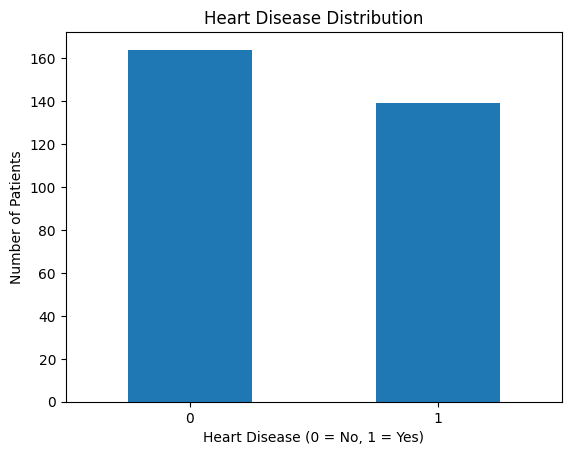

Numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Training samples: 242
Testing samples: 61
Model trining complete
MODEL PERFORMANCE
---------------------------
Accuracy:  0.8852
Precision: 0.8387
Recall:    0.9286
F1 Score:  0.8814

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [23]:
#Exploratory Data Analysis (EDA)
print("Dataset information:")
X.info()

print("\nSummary statistics:")
display(X.describe())

print("\nMissing values:")
print(X.isnull().sum())

print("\nTarget distribution:")
print(y.value_counts())

#visualize the target
y.value_counts().sort_index().plot(kind="bar")

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

#Identify categorical and numerical ccolumns
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal",
    ]


numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

#Split training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

#Preprocess the data
numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_transformer = Pipeline([(
    "imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)
#Create logistic regression
model = Pipeline([("preprocessor", preprocessor), ("classifier", LogisticRegression(max_iter=1000))])

#train it
model.fit(X_train, y_train)
print("Model trining complete")

#predictions
y_pred = model.predict(X_test)


#Calculate Accuracy, Precsion, Recall and F1
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MODEL PERFORMANCE")
print("---------------------------")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))




Confusion Matrix:
[[28  5]
 [ 2 26]]


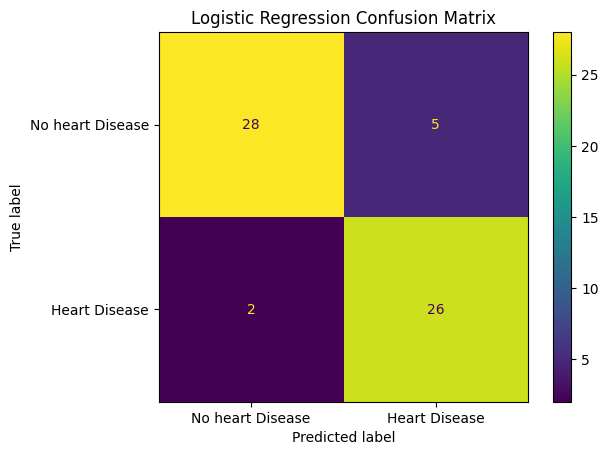

In [24]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No heart Disease", "Heart Disease"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()


Confusion Matrix Interpretation:
The logistic regression model correctly classified 28 patients without heart disease and 26 patients with heart disease. It made 5 false-positive predictions and 2 false-negative predictions. Overall, the model correctly classified 54 of 61 patients, giving an accuracy of approximately 88.5%. The low number of false negatives indicates that the model was effective at identifying patients who actually had heart disease.


Conclusion:
A logistic regression model was developed to predict the presence of heart disease using patient medical attributes. The dataset was explored and preprocessed by handling missing values, encoding categorical variables, and standardizing numerical features.
The model was evaluated using accuracy, precision, recall, F1 score, and a confusion matrix. Recall is particularly important in this application because false-negative predictions may result in patients with heart disease being incorrectly classified as healthy.
Overall, logistic regression provides an interpretable baseline model for predicting heart disease, although additional models and threshold tuning could be explored to improve performance.